In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, RidgeCV
from sklearn.preprocessing import PolynomialFeatures
from matplotlib import cm

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

gpu = torch.device("cuda:0")
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3060


In [3]:
## Constants
num_neurons = 2000
num_i = int(0.1 * num_neurons)
num_e = int(0.9 * num_neurons)
num_channel_inputs = 100
P = 16
D = 10 ** 3
k = 100
novel_inds = torch.arange(0, P // 2)
familiar_inds = torch.arange(P // 2, P)
ie_post = (num_e, num_neurons)
ie_pre = (0, num_e)
ei_post = (0, num_e)
ei_pre = (num_e, num_neurons)
w_ie = 0.5
w_ei = -0.2
mult = 100
# Changed when we re-trained
epochs_inner = 2000
eps = 1e-8
snapshot_every = 20

In [4]:
## Util functions
def get_update_inds(post, pre, W):
    weights_slice = W[post[0]:post[1], pre[0]:pre[1]]
    inds = torch.nonzero(weights_slice, as_tuple=True)
    update_inds = (inds[0] + post[0], inds[1] + pre[0])
    
    return update_inds

def odor_corrs(R, family_inds):
    R_adjusted = R[:num_e, family_inds] - torch.mean(R[:num_e, family_inds], dim=1, keepdim=True)
    R_adjusted.t_()
    sigma_E = torch.corrcoef(R_adjusted) -  torch.eye(P // 2, device=gpu)

    avg_corr = torch.mean(torch.abs(sigma_E))

    return avg_corr, sigma_E

# Sparsity per odor, across all (E) neurons
def sparsity_per_odor(R):
    # Epsilon for if we have zero responses
    eps = 1e-6
    sp_per_odor = 1 - ((torch.sum(R[:num_e], dim=0) ** 2 + eps) / (num_e * (torch.sum(R[:num_e] ** 2, dim=0)) + eps))
    # Sparsity nan means that the responses were all 0 for an odor, meaning that its max sparsity of 1
    return sp_per_odor

# Sparsity per (E) neuron, across a given odor family
def sparsity_per_neuron(R, odor_inds):
    sp_per_neuron = 1 - (
                (torch.sum(R[:num_e, odor_inds], dim=1) ** 2) / ((P // 2) * torch.sum(R[:num_e, odor_inds] ** 2, dim=1)))
    return sp_per_neuron

In [5]:
def create_adj_matrix(p, m, n):
    probs = torch.ones(m, n) * p
    A_mn = torch.bernoulli(probs)
    return A_mn

def correlated_mitral_activity():
    P_prime = 4
    sigma_p_prime = torch.zeros((P_prime, P_prime)).fill_diagonal_(1)
    dist = torch.distributions.MultivariateNormal(torch.zeros(P_prime), sigma_p_prime)
    p_prime_activity = dist.sample(torch.Size([D]))
    var = 1 / P_prime
    projection = torch.normal(torch.zeros((P_prime, P)), torch.ones(P_prime, P) * np.sqrt(var))
    activity = p_prime_activity @ projection
    return activity.to(gpu)

# Computes feedforward (channel) weights mapping mitral activity onto E,I neurons
def compute_feedforward_weights():
    p = num_channel_inputs / D
    with torch.device(gpu):
        a = create_adj_matrix(p, num_e, D)
        b = torch.zeros(size=(num_i, D))
        W_ff = torch.cat(tensors=(a, b), dim=0)

    return W_ff

def compute_initial_recurrent_weights():
    k_ee = k_ei = k_ie = k_ii = k
    #p_ee = k_ee / num_e
    # k inhibitory inputs to that e neuron, out of num_i total inhibitory neurons gives the connection probability per neuron
    p_ei = k_ei / num_i
    p_ie = k_ie / num_e
    #p_ii = k_ii / num_i
    
    # Constants
    #w_ee = 0.1
    w_ei = 0.2
    w_ie = 0.5
    #w_ii = 0.3
    # Ignore ee and ii weights for now:
    p_ee = p_ii = w_ee = w_ii = 0
    with torch.device(gpu):
        W_ee = create_adj_matrix(p_ee, num_e, num_e) * w_ee
        W_ei = create_adj_matrix(p_ei, num_e, num_i) * -w_ei
        W_ie = create_adj_matrix(p_ie, num_i, num_e) * w_ie
        W_ii = create_adj_matrix(p_ii, num_i, num_i) * -w_ii
        
        # Concat
        W_1 = torch.cat(tensors=(W_ee, W_ei), dim=1)
        W_2 = torch.cat(tensors=(W_ie, W_ii), dim=1)
        W_rec = torch.cat(tensors=(W_1, W_2), dim=0)
    
    return W_rec

# Takes in mitral activity I and feedforward weights W_ff and computes feedforward activity h_bar_ff
def compute_feedforward_activity(W_ff, I):
    with torch.device(gpu):
        h_ff = (W_ff @ I) * (1 / np.sqrt(num_channel_inputs))
        h_bar_ff = torch.zeros_like(h_ff)
        # Subtract by mean across (excitatory) neurons for each odor
        h_bar_ff[:num_e] = h_ff[:num_e] - torch.mean(h_ff[:num_e], dim=0, keepdim=True)
    return h_bar_ff

# Computes activation threshold for neurons, right now set it at 0
def compute_threshold():
    threshold = torch.zeros((num_neurons, P), device=gpu)
    # Since inhibitory neurons are linear
    threshold[num_e:, :] = 0
    return threshold

# ReLU for excitatory, linear for inhibitory
def neuron_activations(X):
    # Mask to keep excitatory
    mask1 = torch.ones((num_neurons, 1), device=gpu)
    mask1[num_e:, :] = 0
    # Mask to keep inhibitory
    mask2 = torch.zeros((num_neurons, 1), device=gpu)
    mask2[num_e:, :] = 1
    return (torch.relu(X) * mask1) + (X * mask2)

# Computes R for each odor, with the activation threshold theta
def compute_piriform_response(h_bar_ff, W_rec):
    # The coefficient of x_bar
    tau = 1
    # time step
    dt = 0.1
    # Number of time steps
    T = 200
    
    # Initial condition where states are gaussian
    mu_0 = 0.
    sigma_0 = 0.2
    X_0 = torch.normal(mu_0, sigma_0, size=(num_neurons, P))
    X = X_0.to(gpu)
    
    pts = []
    for i in range(T-2):
        with torch.no_grad():
            part1 = -1 * X
            part2 = (W_rec @ neuron_activations(X)) * (1 / np.sqrt(k))
            part3 = h_bar_ff
            dXdt = (1 / tau) * (part1 + part2 + part3)
            X = X + (dXdt * dt)
   
    # On the last 2 iterations only, track the gradient
    X.requires_grad_(True)
    
    for j in range(2):
        part1 = -1 * X
        part2 = (W_rec @ neuron_activations(X)) * (1 / np.sqrt(k))
        part3 = h_bar_ff
        dXdt = (1 / tau) * (part1 + part2 + part3)
        X = X + (dXdt * dt)
    
    threshold = compute_threshold()
    
    R = neuron_activations(X - threshold)
    
    return R

In [6]:
def compute_update(A, W_rec, R, update_inds, degree, numvars):
    numterms = (degree + 1) ** numvars

    #W_start = W_rec[update_inds].unsqueeze(0).t()
    R_postsyn = R[update_inds[0], :][:, familiar_inds]
    R_presyn = R[update_inds[1], :][:, familiar_inds]

    post = R_postsyn[update_inds[0], :]
    pre = R_presyn[update_inds[1], :]
    # For now no W
    #ws = torch.repeat_interleave(W_rec[update_inds[0], update_inds[1]].unsqueeze(1), repeats=P, dim=1)
    post = post.expand(numterms, -1, -1)
    pre = pre.expand(numterms, -1, -1)
    #ws = torch.repeat_interleave(ws.unsqueeze(0), repeats=numterms, dim=0)
    #ws = ws.expand(numterms, -1, -1)
    #combined = torch.stack((post, pre, ws), dim=1)
    combined = torch.stack((post, pre), dim=1)
    exps = torch.cartesian_prod(*([torch.arange(degree + 1)] * numvars)).to(gpu)
    #exps = exps.unsqueeze(2).unsqueeze(3)
    exps = exps.broadcast_to(combined.shape)
    result = torch.pow(combined, exps)
    sum_terms = torch.prod(result, dim=1)
    A_coef = A.unsqueeze(1).unsqueeze(2)
    result = A_coef * sum_terms
    updates_per_odor = torch.sum(result, dim=0)
    updates = torch.mean(updates_per_odor, dim=1)

    return updates

In [15]:
# Subdivides loss and returns in 2D tensor of (num_intervals, 2) where the second dim gives (epoch_start, epoch_end)
def load_loss(num_intervals, epoch_bound, real, type):
    if epoch_bound == None:
        epoch_bound = (0, epochs_inner-snapshot_every)
    dir = f"../training_scripts/checkpt_train/snapshot20/{type}"
    datapath = f"{dir}/realization_{real}/data"
    corrs = torch.load(f"{datapath}/corrs.pt").detach().cpu()
    corr_region = corrs[epoch_bound[0]: epoch_bound[1]]
    total_reduction = corr_region[-1] - corr_region[0]
    interval = total_reduction / (num_intervals)
    loss_values = corr_region[0] + torch.arange(num_intervals + 1) * interval
    sorted, orig_indices = torch.sort(corr_region)
    inds = torch.bucketize(loss_values, sorted)
    inds = orig_indices[inds]
    epoch_intervals = []
    for i in range(1, num_intervals+1):
        # Round to nearest 100 epochs b/c those are the snapshots we covered
        lower_bound = round(inds[i-1].item() / float(snapshot_every)) * snapshot_every
        upper_bound = round(inds[i].item() / float(snapshot_every)) * snapshot_every
        loss_bounds = (lower_bound, upper_bound)
        epoch_intervals.append(loss_bounds)
    
    return epoch_intervals

# Alpha: how much to weight the regularization (lower for E->I b/c we have less training samples)
def fit_weights(X, Y):
    # L1 ratio - 0.02 is all L2, 1 is all L1
    #reg = ElasticNet(l1_ratio=0.02)
    #reg = RidgeCV(alphas=torch.arange(1, 11) * 0.05)
    #reg = ElasticNet(alpha=alpha, l1_ratio=1.0)
    
    # Already have intercept from power series transform
    reg = LinearRegression(fit_intercept=False)
    reg.fit(X, Y)

    return reg

In [16]:
def prepare_input(post, pre, r, degree=2, num_intervals=5, use_weights=False, epoch_subset=None):
    type = "ie" if (post[1] == num_neurons) else "ei"
    loss_intervals = load_loss(num_intervals, epoch_subset, r, type)

    epoch_start, epoch_end = (0, epochs_inner) if epoch_subset == None else epoch_subset

    interval_samples = []
    interval_labels = []

    dir = f"../training_scripts/checkpt_train/snapshot20/{type}"
    datapath = f"{dir}/realization_{r}/data/snapshots"
    W0 = torch.load(f"{datapath}/epoch_{epoch_start}/W_trained.pt").detach().cpu()
    update_inds = get_update_inds(post, pre, W0)
    
    for i in range(num_intervals):
        start, end = loss_intervals[i]

        W0 = torch.load(f"{datapath}/epoch_{start}/W_trained.pt").detach().cpu()
        Wf = torch.load(f"{datapath}/epoch_{end}/W_trained.pt").detach().cpu()
        R = torch.load(f"{datapath}/epoch_{start}/R_trained.pt").detach().cpu()
        delta_W = Wf[update_inds] - W0[update_inds]

        # Num vars in polynomial (presyn, postsyn, weight)
        numvars = 3 if use_weights else 2
        # Num terms in polynomial is (degree + 1) ** num_vars
        numterms = (degree + 1) ** numvars


        post = R[update_inds[0], :][:, familiar_inds]
        pre = R[update_inds[1], :][:, familiar_inds]

        if use_weights:
            ws = W0[update_inds[0], update_inds[1]].unsqueeze(1).expand((-1, P // 2))
            features = torch.stack((post, pre, ws), dim=1)
        else:
            features = torch.stack((post, pre), dim=1)
        
        features = features.unsqueeze(1).expand((-1, numterms, -1, -1))

        exps = torch.cartesian_prod(*([torch.arange(degree + 1)] * numvars))
        exps = exps.unsqueeze(0).unsqueeze(3).broadcast_to(features.shape)

        transformed_features = torch.pow(features, exps).prod(dim=2, keepdim=False)
        transformed_features = transformed_features.mean(dim=-1)
        interval_samples.append(transformed_features)
        interval_labels.append(delta_W)

    all_samples = torch.cat(interval_samples, dim=0)
    all_labels = torch.cat(interval_labels, dim=0)

    samples_mu = torch.mean(all_samples, dim=0, keepdim=True)
    samples_std = torch.std(all_samples, dim=0, keepdim=True)
    normed_samples = (all_samples - samples_mu) / (samples_std + eps)

    # Z-scoring - we don't do that for now
    # Y_mu = torch.mean(all_labels, dim=0, keepdim=True)
    # Y_std = torch.std(all_labels, dim=0, keepdim=True)
    # normed_Y = (all_labels - Y_mu) / (Y_std + eps)

    return normed_samples, all_labels, update_inds

In [17]:
def predicted_responses(reg, post, pre, r, degree=2, num_intervals=5, epoch_subset=None, random_init=False, use_weights=False):
    type = "ie" if (post[1] == num_neurons) else "ei"

    epoch_start, epoch_end = (0, epochs_inner) if epoch_subset == None else epoch_subset
    
    X, _, update_inds = prepare_input(post, pre, r, degree=degree, num_intervals=num_intervals, use_weights=use_weights, epoch_subset=None)

    dir = f"../training_scripts/checkpt_train/snapshot20/{type}"
    datapath = f"{dir}/realization_{r}/data/snapshots"
    if random_init:
        I = correlated_mitral_activity()
        W_ff = compute_feedforward_weights()
        W0 = compute_initial_recurrent_weights()
        hbar_ff = compute_feedforward_activity(W_ff, I)
        R0 = compute_piriform_response(hbar_ff, W0)
    else:
        I = torch.load(f"{dir}/realization_{r}/data/I.pt").detach()
        W_ff = torch.load(f"{dir}/realization_{r}/data/W_ff.pt").detach()
        hbar_ff = compute_feedforward_activity(W_ff, I)
        W0 = torch.load(f"{datapath}/epoch_{epoch_start}/W_trained.pt").detach()
        R0 = torch.load(f"{datapath}/epoch_{epoch_start}/R_trained.pt").detach()

    delta_pred = torch.from_numpy(reg.predict(X))
    W_pred = W0.clone()
    W_pred[update_inds] = W0[update_inds] + delta_pred.to(gpu)
    R_pred = compute_piriform_response(hbar_ff, W_pred.to(gpu))

    start_corrs = (odor_corrs(R0, novel_inds)[0].item(), odor_corrs(R0, familiar_inds)[0].item())
    start_sp = sparsity_per_odor(R0)
    pred_corrs = (odor_corrs(R_pred, novel_inds)[0].item(), odor_corrs(R_pred, familiar_inds)[0].item())
    pred_sp = sparsity_per_odor(R_pred)

    if not random_init:
        Rf = torch.load(f"{datapath}/epoch_{epoch_end-snapshot_every}/R_trained.pt").detach()
        true_corrs = (odor_corrs(Rf, novel_inds)[0].item(), odor_corrs(Rf, familiar_inds)[0].item())
        true_sp = sparsity_per_odor(Rf)
        out_corrs = (start_corrs, pred_corrs, true_corrs)
        out_sp = (start_sp, pred_sp, true_sp)
    else:
        out_corrs = (start_corrs, pred_corrs)
        out_sp = (start_sp, pred_sp)

    return out_corrs, out_sp

In [18]:
def plot_weight_fitting(post, pre, degree, r, num_intervals=5, use_weights=True, sample_subset=None, epoch_subset=None):
        X, Y, _ = prepare_input(post, pre, r=r, num_intervals=num_intervals, degree=degree, use_weights=use_weights, epoch_subset=epoch_subset)
        if sample_subset == None:
                sample_subset = X.shape[0]
        X, Y, _ = prepare_input(post, pre, r=r, epoch_subset=None)
        reg = fit_weights(X, Y)
        coords = torch.arange(X.shape[0])

        sample = torch.randperm(coords.shape[0])[:sample_subset]
        sort, inds = torch.sort(Y)
        print(reg.coef_)
        fig = plt.figure(figsize=(7, 5))
        plt.scatter(coords[sample], reg.predict(X)[inds][sample], color="tab:red", s=1, alpha=0.5, label="Predicted")
        plt.scatter(coords[sample], sort[sample], color="tab:blue", s=1, label="Actual")
        plt.text(0.5, 0.5, f"R^2: {reg.score(X, Y):.3f}", transform=fig.get_axes()[0].transAxes)
        plt.axhline(torch.mean(Y), color="tab:green", label="Data Mean")
        plt.legend()
        plt.ylabel("delta W")
        plt.xlabel("Sample")

        return fig, reg

[ 0.          0.06064036 -0.02955616 -0.05949229  0.02809641 -0.01195233
  0.05317368 -0.05793408  0.0277507 ]


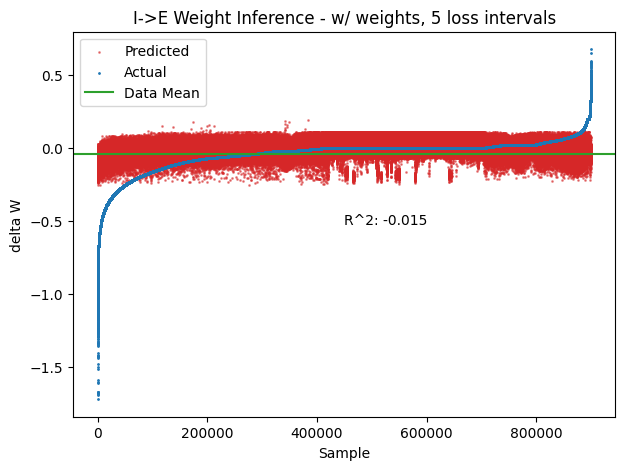

[ 0.         -0.08389305  0.04005948  0.18086292  0.33830816 -0.19321983
 -0.11253394  0.05760548 -0.15836018]


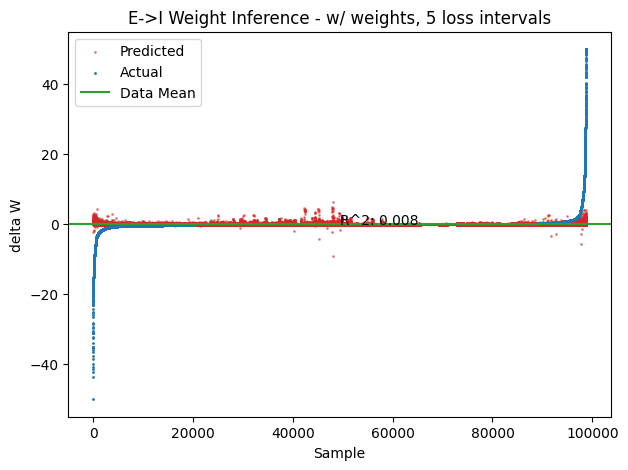

In [19]:
real = 1
degree = 2
intervals = 5

fig, reg_ei = plot_weight_fitting(ei_post, ei_pre, degree=degree, num_intervals=intervals, r=real, use_weights=True, epoch_subset=None)
plt.title(f"I->E Weight Inference - w/ weights, {intervals} loss intervals")
plt.show()
plt.close(fig)

fig, reg_ie = plot_weight_fitting(ie_post, ie_pre, degree=degree, num_intervals=intervals, r=real, use_weights=True, sample_subset=100000, epoch_subset=None)
plt.title(f"E->I Weight Inference - w/ weights, {intervals} loss intervals")
plt.show()
plt.close(fig)

[ 0.          0.06064036 -0.02955616 -0.05949229  0.02809641 -0.01195233
  0.05317368 -0.05793408  0.0277507 ]


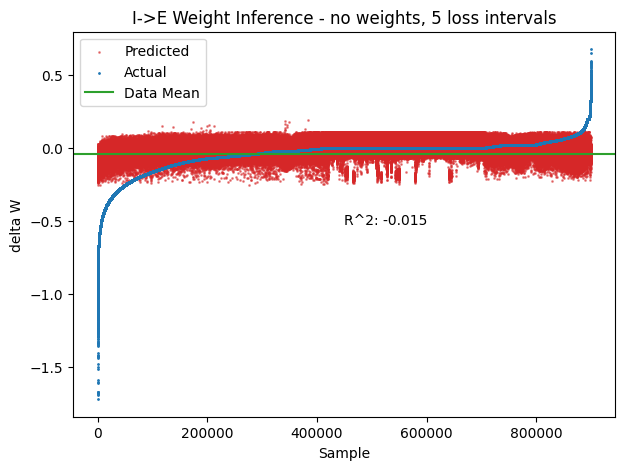

[ 0.         -0.08389305  0.04005948  0.18086292  0.33830816 -0.19321983
 -0.11253394  0.05760548 -0.15836018]


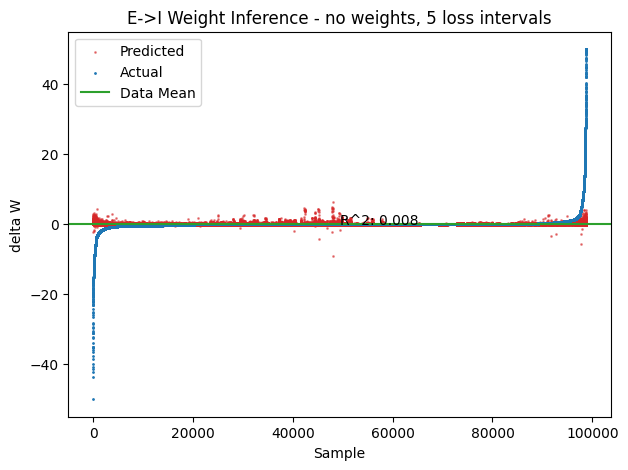

In [20]:
real = 1
degree = 2
intervals = 5

fig, _ = plot_weight_fitting(ei_post, ei_pre, degree=degree, num_intervals=intervals, r=real, use_weights=False, epoch_subset=None)
plt.title(f"I->E Weight Inference - no weights, {intervals} loss intervals")
plt.show()
plt.close(fig)

fig, _ = plot_weight_fitting(ie_post, ie_pre, degree=degree, num_intervals=intervals, r=real, use_weights=False, sample_subset=100000, epoch_subset=None)
plt.title(f"E->I Weight Inference - no weights, {intervals} loss intervals")
plt.show()
plt.close(fig)


In [21]:
def generate_spars_plot(spars):
    num_plots = spars.shape[1]
    start = 0.5
    space = 1
    plot_space = 1.5
    width = space / 2
    spars_coords = torch.Tensor([start, start+space])
    spread = (torch.rand(size=(P // 2,)) - start) * width
    plot_coords = torch.hstack([torch.repeat_interleave(spars_coords[0], repeats=num_plots), torch.repeat_interleave(spars_coords[1], repeats=num_plots)])
    plot_coords[:num_plots] = plot_coords[:num_plots] + (torch.arange(num_plots) * (space + plot_space))
    plot_coords[num_plots:] = plot_coords[num_plots:] + (torch.arange(num_plots) * (space + plot_space))
    spread = torch.repeat_interleave(spread.unsqueeze(0), repeats=num_plots, dim=0)

    plt.scatter(spread + plot_coords[:num_plots].unsqueeze(1), spars[novel_inds, :].detach().cpu(), label="Novel")
    plt.scatter(spread + plot_coords[num_plots:].unsqueeze(1), spars[familiar_inds, :].detach().cpu(), label="Familiar")
    labels = ["start", "pred_end"]
    if num_plots == 3:
        labels.append("true_end")
    plt.xticks(ticks=plot_coords[:num_plots] + width, labels=labels)
    plt.xlim(left=plot_coords[0]-(1.5*width), right=plot_coords[-1]+(1.5*width))
    plt.ylim(0, 1.1)
    plt.bar(plot_coords[:num_plots], torch.mean(spars[novel_inds, :], dim=0).detach().cpu(), width = width, alpha=0.5, color="green")
    plt.bar(plot_coords[num_plots:], torch.mean(spars[familiar_inds, :], dim=0).detach().cpu(), width = width, alpha=0.5, color="green")
    plt.legend(loc="lower left")

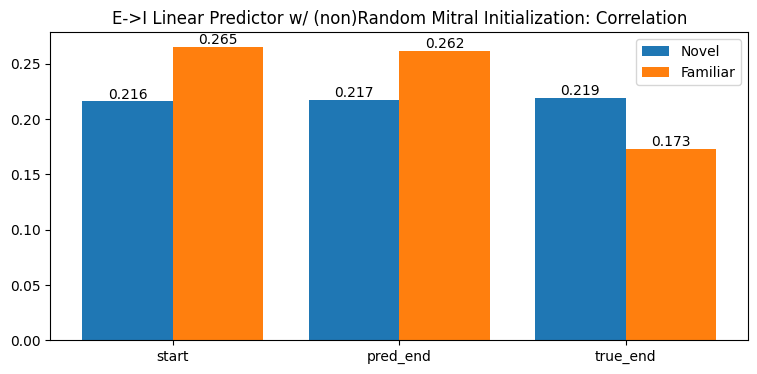

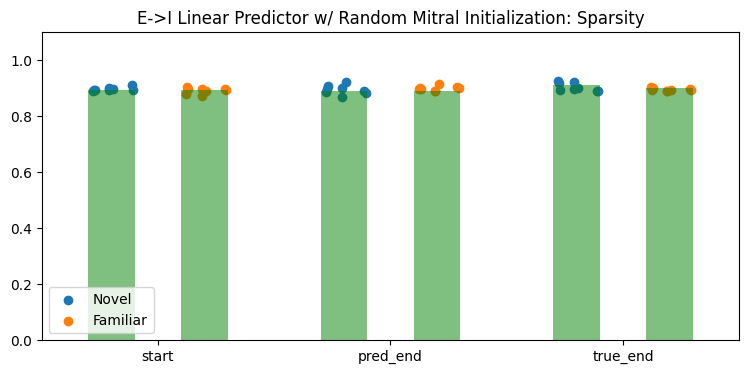

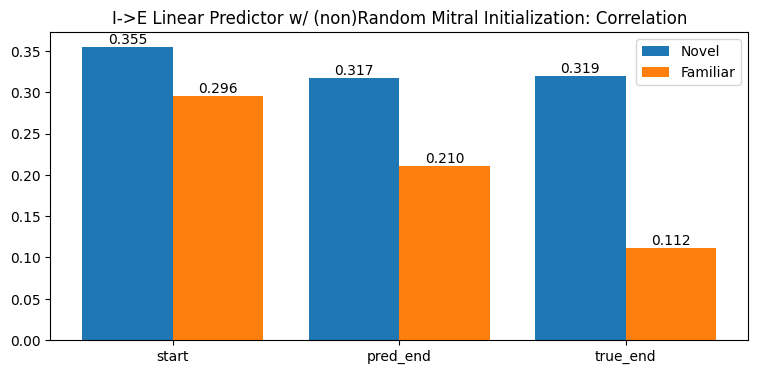

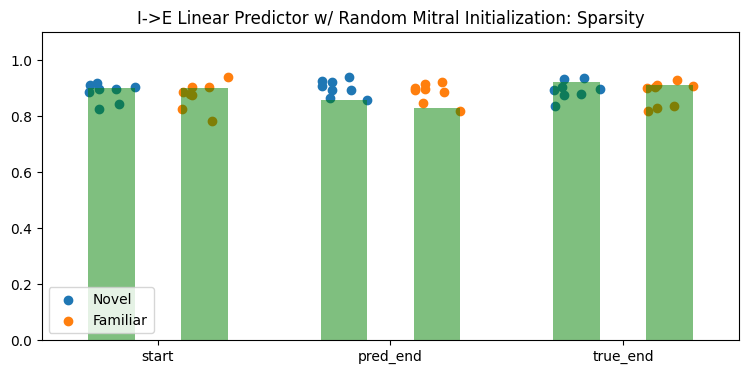

In [22]:
def plot_decorrelation(corr_title, sp_title, post, pre, degree, r, num_intervals, do_rand=False, use_weights=False, epoch_subset=None):
    reg = fit_weights(*prepare_input(post, pre, degree=degree, num_intervals=num_intervals, r=real, use_weights=use_weights, epoch_subset=epoch_subset)[0:2])
    corrs, spars = predicted_responses(reg, post, pre, r=real, degree=degree, num_intervals=num_intervals, random_init=do_rand, use_weights=use_weights)

    fig = plt.figure(figsize=(9, 4))
    width = 0.5
    space = width / 4
    arr_corrs = np.array(corrs)
    bc1 = plt.bar(torch.arange(arr_corrs.shape[0])*(width + space), arr_corrs[:, 0], width = width / 2, color="tab:blue", label="Novel")
    bc2 = plt.bar(torch.arange(arr_corrs.shape[0])*(width + space) + width / 2, arr_corrs[:, 1], width = width / 2, color="tab:orange", label="Familiar")
    plt.bar_label(bc1, fmt="%.3f")
    plt.bar_label(bc2, fmt="%.3f")
    plt.legend()
    labels = ["start", "pred_end"]
    if arr_corrs.shape[0] == 3:
        labels.append("true_end")
    plt.xticks(torch.arange(arr_corrs.shape[0])*(width + space) + width / 4, labels=labels)
    plt.title(corr_title)
    plt.show()
    plt.close(fig)

    fig = plt.figure(figsize=(9, 4))
    sp = torch.stack(spars, dim=1)
    generate_spars_plot(sp)

    plt.title(sp_title)
    plt.show()
    plt.close(fig)


do_rand=False
corr_title = "E->I Linear Predictor w/ (non)Random Mitral Initialization: Correlation"
sp_title = "E->I Linear Predictor w/ Random Mitral Initialization: Sparsity"
corr_fig = plot_decorrelation(corr_title, sp_title, ie_post, ie_pre, degree=degree, num_intervals=1, r=2, do_rand=do_rand, use_weights=False, epoch_subset=None)
plt.show()

corr_title = "I->E Linear Predictor w/ (non)Random Mitral Initialization: Correlation"
sp_title = "I->E Linear Predictor w/ Random Mitral Initialization: Sparsity"
corr_fig = plot_decorrelation(corr_title, sp_title, ei_post, ei_pre, degree=degree, num_intervals=1, r=4, do_rand=do_rand, use_weights=False, epoch_subset=None)
plt.show()

In [23]:
def compare_coefs(degree, numvars, coef):
    n = degree + 1
    coefs = np.reshape(coef, tuple([n] * numvars))
    fig, ax = plt.subplots(nrows=n, ncols=n, sharex=True, sharey=True, constrained_layout=True)
    for i in range(n):
        for j in range(n):
            ax[i, j].bar(torch.arange(n), coefs[i][j])
            ax[i, j].set_xticks(torch.arange(n))
            if (i, j) == (0, 0):
                ax[i, j].set_ylabel("coef")
            if (i, j) == (n-1, n-1):
                ax[i, j].set_xlabel("degree w_start")

    fig.supxlabel("degree pre")
    fig.supylabel("degree post")

    fig.suptitle("Linear Predictor Coefficients")    
    plt.show()
    # E->I: Biggest term is linear increase in weights
    # I->E: [1, 1] covariance term has big increase w/ and w/o weights


compare_coefs(degree=degree, numvars=3, coef=reg_ei.coef_)

ValueError: cannot reshape array of size 9 into shape (3,3,3)

In [ ]:
# # For I->E, train on single realization and decorrelate
# reals = [i for i in range(5)]
# # Width of bars
# width = 0.2
# # Offset between groups of bars
# offset = 0.5 * width
# num_bars = len(reals) + 2
# x = torch.arange(len(reals)) * num_bars * (width + offset)
# for i in reals:
#     X_fit, Y_fit, _ = prepare_input(ei_post, ei_pre, r=i, epoch_subset=None)
#     reg = fit_weights(X_fit, Y_fit)
#     corrs = []
#     for r in reals:
#         corr, _ = predicted_responses(reg, ei_post, ei_pre, r, familiar_inds, epoch_subset=None, random_init=False)
#         if r == i:
#             prev_corrs = corrs
#             corrs = list(corr[:2])
#             corrs.extend(prev_corrs)
        
#         corrs.append(corr[2])

#     colors = ["tab:blue"] * num_bars
#     colors[0] = "tab:red"
#     colors[1] = "tab:orange"
#     colors[num_bars-len(reals)+i] = "tab:green"

#     if i == len(reals) - 1:
#         labels = [""] * num_bars
#         labels[0] = "start"
#         labels[1] = "true_end"
#         labels[num_bars-len(reals)+i] = "self-prediction"
#     else:
#         labels = [None] * 7

#     plt.bar(x[i] + torch.arange(num_bars) * width, corrs, width=width, edgecolor="black", color=colors, label=labels)

# plt.xticks(x + (num_bars // 2 * width), labels=reals)
# plt.legend()
# plt.title("(Familiar) Odor Correlation from Linear Model Prediction on I->E Realizations")
# plt.xlabel("Trained Realization")
# plt.ylabel("Average Odor Correlation")
# plt.show()

TypeError: expand(): argument 'size' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got Tensor"

In [ ]:
# new_coef = np.copy(reg_ei.coef_)
# new_coef[[0, 1, 3, 4, 5]] = 0
# corrs, spars = predicted_responses(new_coef, reg_ei.intercept_, ei_post, ei_pre, 3, familiar_inds, epoch_start=0, epoch_end=epochs_inner)
# fig = plt.figure(figsize=(9, 4))
# bc1 = plt.bar(torch.arange(len(corrs)), corrs, tick_label=["start", "true_end", "pred"])
# plt.bar_label(bc1, fmt="%.3f")
# plt.show()

# fig = plt.figure(figsize=(8, 3))
# bc1 = plt.bar(torch.arange(len(spars)), spars, tick_label=["start", "true_end", "full_pred"])
# plt.bar_label(bc1, fmt="%.3f")
# plt.show()

# TODO make sparsity work
# Y_hat, Y = pred_weights(new_coef, reg_ei.intercept_, ei_post, ei_pre, 3, epoch_start=0, epoch_end=epochs_inner, regime="normal")
# coords = torch.arange(Y_hat.shape[0])
# sort, inds = torch.sort(Y)
# fig = plt.figure(figsize=(7, 5))
# plt.scatter(coords, Y_hat[inds], color="tab:red", s=1, label="Predicted")
# plt.scatter(coords, sort, color="tab:blue", s=1, label="Actual")
# plt.show()
# plt.close(fig)

# When we train I->E on full set of features but then predict with only the postsynaptic (E) mean, we decorrelate well
# However, when we train using only postsynaptic mean/var as features, we don't decorrelate well (maybe more features can account for noise?)
# Excitatory neruons which have mean response 0 won't propagate loss through them, so their weights won't change (and the change is just given by the intercept)

# Two cases by which a neuron could have high mean across odors:
# 1. it responds uniformly to a lot of odors (and thereby has low variance)
# 2. it responds selectively to some odors but very strongly to those (and thereby has a high variance)
# In the feature weighting, since the mean was very high, if case 2 was true then it would still be able to decorrelate by inhibiting neurons with high variance
# However, this isn't the case since when we took out the mean we stopped being able to decorrelate
# Thus, hypothesis is that we have selective inhibition for neurons which respond to lots of odors, thereby decorrelating the response between any pair of odors
# This inhibition doesn't have to push the neuron below its activation threshold and thus population sparsity doesn't have to change


TypeError: predicted_responses() got an unexpected keyword argument 'only_E'